Naive baseline accuracy: 0.71


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


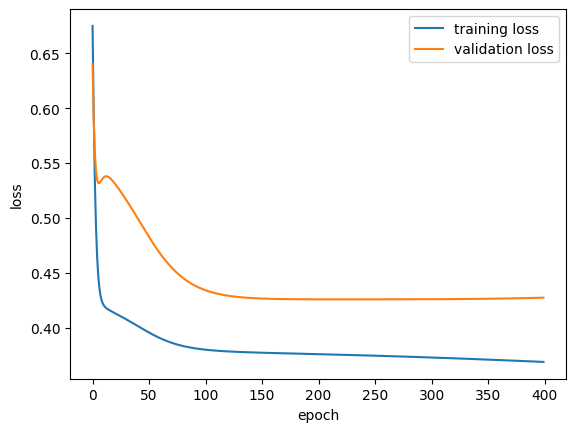

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7400 - loss: 0.6231
Neural Network test accuracy: 0.7400000095367432
Logistic Regression test accuracy: 0.75
Naive baseline:       0.710
Logistic Regression:  0.750
Neural Network:       0.740


In [3]:
# ===== STAGE 1: DATA GENERATION =====
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 500

age = np.random.normal(35, 10, n_samples).clip(18, 70)
income = np.random.normal(50000, 15000, n_samples).clip(10000, 150000)
visits = np.random.poisson(5, n_samples)
session_duration = np.random.normal(8, 3, n_samples).clip(0.5, 30)
income_scaled = income / 50000
visits_scaled = visits / 5
interaction = income_scaled * visits_scaled

z = (
    0.05 * visits +
    0.03 * session_duration -
    0.02 * age -
    3.0 +
    1.5 * interaction
)

probability = 1 / (1 + np.exp(-z))
purchased = np.random.binomial(1, probability)

data = pd.DataFrame({
    'age': age,
    'income': income,
    'visits': visits,
    'session_duration': session_duration,
    'purchased': purchased
})
data.head()
# ===== STAGE 2: TRAIN/TEST SPLIT + SCALING =====
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[['age', 'income', 'visits', 'session_duration']]
y = data['purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

naive_accuracy = 1 - y_test.mean()
print("Naive baseline accuracy:", naive_accuracy)

# ===== STAGE 3 + 4: NEURAL NETWORK (longer training) =====
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

tf.random.set_seed(42)

model = Sequential()
model.add(Dense(units=25, activation='sigmoid', input_shape=(4,)))
model.add(Dense(units=15, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=400,
    validation_split=0.1,
    verbose=0
)

plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print("Neural Network test accuracy:", test_accuracy)

# ===== BASELINE COMPARISON: LOGISTIC REGRESSION =====
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_reg_accuracy = log_reg.score(X_test_scaled, y_test)
print("Logistic Regression test accuracy:", log_reg_accuracy)

# ===== FINAL COMPARISON =====
print(f"Naive baseline:       {naive_accuracy:.3f}")
print(f"Logistic Regression:  {log_reg_accuracy:.3f}")
print(f"Neural Network:       {test_accuracy:.3f}")